# TI-DeepONet in Neuromancer: DeepONets integrated with numerical time schemes

Recreating TI-DeepONet (Time-integrated Deep Operator Network) Heat equation notebook example in Neruomancer from (https://github.com/Centrum-IntelliPhysics/PDEControl_DPC/tree/main).

Here, we use a new DeepONet, `dde.nn.MIONetCartesianProd`, from DeepXDE which is a two-branch, one-trunk DeepONet using a cartesian grid. The problem is fully data driven, as in [Part1](./Part_1_DeepONet_antiderivative_aligned.ipynb) and [Part2](./Part_2_DeepONet_antiderivative_unaligned.ipynb). This example presents the most complicated DeepONet example implemented in Neuromancer.

<!-- <img src="https://github.com/Centrum-IntelliPhysics/PDEControl_DPC/blob/main/DPC_NO.png" width="700"> -->
<img src="https://arxiv.org/html/2505.17341v2/x2.png?raw=true" width="700">

## Time-integrated Deep Operator Network (TI-DeepONet)

**Scope.** In this notebook, we only focus on the **operator learning** part from [[2]](https://arxiv.org/abs/2511.08992). The framework, referred to as TI-DeepONet (Time-integrated Deep Operator Network), is designed to parametrize both state and control outputs to solve the system dynamics efficiently. Here, we

- Learn a differentiable surrogate model of the PDE dynamics
- Predict temporal derivatives and integrate using numerical schemes (Euler/RK4)
- Preserve temporal causality while minimizing error accumulation

### References

[1] [Nayak, D., & Goswami, S. (2025). TI-DeepONet: Learnable Time Integration for Stable Long-Term Extrapolation. arXiv preprint arXiv:2505.17341.](https://arxiv.org/abs/2505.17341)

[2] [Sarkar, D. R., Drgoňa, J., & Goswami, S. (2025). Learning to Control PDEs with Differentiable Predictive Control and Time-Integrated Neural Operators. arXiv preprint arXiv:2511.08992.](https://arxiv.org/abs/2511.08992)


## Problem Setup

### 1. TI-DON Parametrisation
* **State Dynamics ($\mathcal{G}_\theta$):** We train a neural operator $\mathcal{G}_\theta$ to learn the instantaneous time derivative:
    $$
    \mathcal{G}_\theta : (u(t), f(t)) \mapsto \partial_t u
    $$
    This learned operator is integrated using **RK4** (Runge-Kutta 4) for time evolution.
    
* **Control Representation ($f$):** Control inputs are parametrized via **Gaussian basis functions**:
    $$
    f(x, t) = \sum_{i=1}^{n} f_i(t) \cdot \exp \left( - \frac{(x - \mu_i)^2}{2\sigma^2} \right)
    $$
    * **Actuators:** $n=4$ actuators at $\mu_i \in \{0.2, 0.4, 0.6, 0.8\}$ with spread $\sigma = 0.1$.
    * **Amplitudes:** $f_i(t)$ are learned time-varying amplitudes bounded by $|f_i(t)| \le 40$.

### 2. Physical System: Heat Equation
The underlying dynamics follow the Heat Equation with homogeneous Dirichlet boundary conditions:
$$
\frac{\partial u}{\partial t} = \alpha \frac{\partial^2 u}{\partial x^2} + f(x, t), \quad x \in [0, 1], ~ t \in [0, 0.4]
$$
where $\alpha = 0.1$ is the thermal diffusivity.


### Imports

In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn


In [2]:
# Set default dtype to float32
torch.set_default_dtype(torch.float)
# PyTorch random seed
seed = 1234
torch.manual_seed(seed)
# NumPy random seed
np.random.seed(seed)

# Device configuration
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: cuda


## Dataset

### Data Generation
* **Method:** Finite Difference Method (FDM) with the unconditionally stable **Crank-Nicolson scheme**.
* **Dataset:** 3000 samples with initial conditions from a Gaussian Random Field (GRF).
* **Resolution:** Spatial $\Delta x = 10^{-2}$, Temporal $\Delta t = 10^{-3}$.

The training and testing datasets for all heat equation PDE systems is available at this [link](https://livejohnshopkins-my.sharepoint.com/:f:/g/personal/droysar1_jh_edu/ElrQ5bd7MKRLv5bfn3_Rg9gBBbJHXQHOztZ37scwJGjbqQ?e=aOTLQC). 

Download `heat_smooth_f_dataset.npz`


In [3]:
data_path = "/home/pk222/projects/PDEControl_DPC/datasets/heat_smooth_f_dataset.npz"

In [4]:
dataset = np.load(data_path)  # total 3000 samples available
samples_to_load = 100

solutions = torch.from_numpy(
    dataset["solutions"][:samples_to_load]
)  # shape: (samples, T+1, N)
controls = torch.from_numpy(
    dataset["controls"][:samples_to_load]
)  # shape: (samples, T, 4)
x_cord = torch.from_numpy(dataset["x"]).reshape(-1, 1)  # shape: (N, 1)
dt = dataset["dt"]  # likely a scalar numpy value

print(f"Loaded {samples_to_load}/{dataset['solutions'].shape[0]} samples:")
print("solutions:", solutions.shape)
print("controls:", controls.shape)
print("x:", x_cord.shape)
print("dt:", dt)


Loaded 100/3000 samples:
solutions: torch.Size([100, 401, 100])
controls: torch.Size([100, 400, 4])
x: torch.Size([100, 1])
dt: 0.001


In [5]:
# Sequences for rollout
U = solutions  # (samples, T+1, N)
F = controls  # (samples, T, 4)
outputs = U  # rollout target (includes initial state)

u0 = U[:, 0:1, :]  # (samples, 1, N) initial condition
u_t_seq = U[:, :-1, :]  # (samples, T, N):
u_next = U[:, 1:, :]  # (samples, T, N)
f_t_seq = F  # (samples, T, 4)

print("U: ", str(U.shape))
print("F: ", str(F.shape))
print("outputs: ", str(outputs.shape))
print("u0: ", str(u0.shape))
print("u_t_seq: ", str(u_t_seq.shape))
print("u_next: ", str(u_next.shape))
print("f_t_seq: ", str(f_t_seq.shape))


U:  torch.Size([100, 401, 100])
F:  torch.Size([100, 400, 4])
outputs:  torch.Size([100, 401, 100])
u0:  torch.Size([100, 1, 100])
u_t_seq:  torch.Size([100, 400, 100])
u_next:  torch.Size([100, 400, 100])
f_t_seq:  torch.Size([100, 400, 4])


### **TI-DeepONet Architecture**

The TI-DeepONet is modified to handle control problems by splitting the "Branch" network into two separate parts.

**1. The Branches (Input Encoders)**
Instead of a single input branch, there are two specialized branches that are multiplied together:
* **State Branch ($b^u$):** Encodes the current state of the system, $u$ (the solution field).
* **Control Branch ($b^f$):** Encodes the external control input, $f$ (the control function).

These two outputs are combined using **element-wise multiplication** ($b^u \odot b^f$) to capture how the state and control interact.

**2. The Trunk (Coordinate Encoder)**
* **Trunk Network ($t$):** This part remains standard. It takes the spatial coordinates (query locations $\zeta$) as input and outputs features based on the grid location.

**3. The Final Output**
The network predicts the **time derivative** ($\partial u / \partial t$) rather than the future state directly. It does this by taking the dot product of the combined branches and the trunk:

$$
\frac{\partial u}{\partial t} \approx \sum_{j=1}^{p} \left[ b_j^u(u^i) \odot b_j^f(f^i) \right] t_j(\zeta)
$$

In [6]:
# Optional: flattened view for single-step training convenience
branch_x1 = u_t_seq.reshape(-1, u_t_seq.shape[-1])  # (samples*T, 100)
branch_x2 = f_t_seq.reshape(-1, f_t_seq.shape[-1])  # (samples*T, 4)
outputs_flat = u_next.reshape(-1, u_next.shape[-1])  # (samples*T, 100)

print("branch_x1: ", str(branch_x1.shape))
print("branch_x2: ", str(branch_x2.shape))
print("outputs_flat: ", str(outputs_flat.shape))


branch_x1:  torch.Size([40000, 100])
branch_x2:  torch.Size([40000, 4])
outputs:  torch.Size([40000, 100])


### Time handling for System rollouts

Flattening (samples × time) is convenient for one-step training, but for System rollouts we keep time in `U`/`F` sequences. The DeepONet still only sees 2D slices `(u_k, f_k)`; `System` handles time by slicing per step.


In [6]:
# Shuffle indices (do this on CPU for convenience)
num_samples = U.shape[0]
g = torch.Generator(device="cpu").manual_seed(seed)
idx = torch.randperm(num_samples, generator=g, device="cpu")

print("Shuffled indices: ", str(idx))

U = U[idx]
F = F[idx]
outputs = outputs[idx]

u0 = U[:, 0:1, :]
u_t_seq = U[:, :-1, :]
u_next = U[:, 1:, :]
f_t_seq = F


Shuffled indices:  tensor([75, 67, 30, 51, 48, 19, 18, 34,  1, 46, 13, 69, 22, 14, 39, 92, 76, 66,
         7, 16, 78, 72, 94, 56, 11, 82, 77, 64,  6, 36, 24, 87, 21,  9,  5, 50,
        70,  8, 62, 33, 91, 80, 74, 98, 79, 44, 59, 68, 83, 37, 10,  0, 55, 73,
        90, 96, 20, 57, 40, 31, 86, 88, 42, 52, 93, 81,  3, 60, 47, 43, 99, 85,
        97, 38, 27, 84, 71, 17, 45, 32, 23, 89, 35, 58, 15, 61, 28, 53,  2, 26,
        65, 12, 29,  4, 49, 41, 25, 95, 54, 63])


In [7]:
# split
train_frac = 0.8  # percentage
n_train = int(train_frac * num_samples)

print("Number of training samples: ", n_train)

Number of training samples:  80


### Create named dictionary datasets for NeuroMANCER

In [8]:
from neuromancer.dataset import DictDataset

trunk_grid = torch.as_tensor(x_cord, dtype=torch.float32).reshape(-1, 1)


def build_dictdataset(u0_seq, f_seq, y_seq, name):
    trunk_inputs = trunk_grid.expand(u0_seq.shape[0], -1, -1)  # (samples, 100, 1)
    return DictDataset(
        {
            "U": y_seq.float(),  # (samples, T+1, 100)
            "F": f_seq.float(),  # (samples, T, 4)
            "u_t": u0_seq.float(),  # (samples, 1, 100)
            "f_t": f_seq.float(),  # (samples, T, 4)
            "trunk_inputs": trunk_inputs.float(),  # (samples, 100, 1)
            "outputs": y_seq.float(),  # (samples, T+1, 100)
        },
        name=name,
    )


train_ds = build_dictdataset(u0[:n_train], F[:n_train], outputs[:n_train], "train")
test_ds = build_dictdataset(u0[n_train:], F[n_train:], outputs[n_train:], "test")


In [9]:
# check dimensions
print("Dimensions check train:")
print("U (sequence):", train_ds.datadict["U"].shape)
print("F (sequence):", train_ds.datadict["F"].shape)
print("u_t (init):", train_ds.datadict["u_t"].shape)
print("f_t (sequence):", train_ds.datadict["f_t"].shape)
print("trunk_inputs:", train_ds.datadict["trunk_inputs"].shape)
print("outputs (sequence):", train_ds.datadict["outputs"].shape)

print("Dimensions check test:")
print("U (sequence):", test_ds.datadict["U"].shape)
print("F (sequence):", test_ds.datadict["F"].shape)
print("u_t (init):", test_ds.datadict["u_t"].shape)
print("f_t (sequence):", test_ds.datadict["f_t"].shape)
print("trunk_inputs:", test_ds.datadict["trunk_inputs"].shape)
print("outputs (sequence):", test_ds.datadict["outputs"].shape)


Dimensions check train:
U (sequence): torch.Size([80, 401, 100])
F (sequence): torch.Size([80, 400, 4])
u_t (init): torch.Size([80, 1, 100])
f_t (sequence): torch.Size([80, 400, 4])
trunk_inputs: torch.Size([80, 100, 1])
outputs (sequence): torch.Size([80, 401, 100])
Dimensions check test:
U (sequence): torch.Size([20, 401, 100])
F (sequence): torch.Size([20, 400, 4])
u_t (init): torch.Size([20, 1, 100])
f_t (sequence): torch.Size([20, 400, 4])
trunk_inputs: torch.Size([20, 100, 1])
outputs (sequence): torch.Size([20, 401, 100])


### Create torch DataLoaders for the Trainer

In [10]:
batch_size = 25
print(f"batch_size: {batch_size}")

# Do this on device, as it needs to for Training
g_device = torch.Generator(device=device).manual_seed(seed)

batch_size: 25


Randomly sample from training data set 1000 times per epoch, with `replacement=True`. This means there's a chance to pick up the same data again. This fully random sampling allows efficient learning of the representation of the gradient.

In [11]:
steps_per_epoch = 1000
num_samples = steps_per_epoch * batch_size

sampler = torch.utils.data.RandomSampler(
    train_ds,
    replacement=True,
    num_samples=num_samples,
    generator=g_device,
)

train_loader = torch.utils.data.DataLoader(
    train_ds,
    batch_size=batch_size,
    sampler=sampler,
    collate_fn=train_ds.collate_fn,
    drop_last=True,
    shuffle=False,  # must be False when sampler is provided
)

In [12]:
# Only shuffle the training set
test_loader = torch.utils.data.DataLoader(
    test_ds,
    batch_size=batch_size,
    collate_fn=test_ds.collate_fn,
    shuffle=False,
)

## Exporting DeepONet from DeepXDE in Neuromancer

We use the DeepONets available in the `dde.nn` library within Neuromancer. Here, we use `dde.nn.MIONetCartesianProd` with the PyTorch backend `os.environ["DDE_BACKEND"] = "pytorch"`. This architecture allows the usage of two input branches along with a trunk. 

Code: (https://deepxde.readthedocs.io/en/latest/_modules/deepxde/nn/pytorch/mionet.html#MIONetCartesianProd)


In [13]:
os.environ["DDE_BACKEND"] = "pytorch"
import deepxde as dde

activation = {
    "branch1": "gelu",
    "branch2": "gelu",
    "trunk": "tanh",
}

hidden_dim = 100

layer_sizes_branch1 = [100, 128, 128, 128, hidden_dim]  # u_t: (B,100) -> (B,100)
layer_sizes_branch2 = [4, 32, 32, 32, hidden_dim]  # f_t: (B,4)   -> (B,100)
layer_sizes_trunk = [1, 64, 64, 64, hidden_dim]  # x:   (100,1) -> (100,100

Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


In [14]:
net = dde.nn.MIONetCartesianProd(
    layer_sizes_branch1=layer_sizes_branch1,
    layer_sizes_branch2=layer_sizes_branch2,
    layer_sizes_trunk=layer_sizes_trunk,
    activation=activation,
    kernel_initializer="Glorot normal",  # weight initialisation available in DeepXDE
    trunk_last_activation=True,  # matches the JAX trunk applying tanh after every Dense
    merge_operation="mul",  # y_func = y_func1 * y_func2
    layer_sizes_merger=None,  # no extra merger MLP
    layer_sizes_output_merger=None,  # keep dot-product einsum
)

A wrapper is needed for the DictDataset format to work with DeepXDE models.
`DeepXDEWrapper` makes DeepXDE models compatible with NeuroMANCER Nodes and supports one or two branches. It fixes the `trunk_input` broadcast.

In [15]:
from neuromancer.modules.operators import DeepXDEWrapper

deeponet_wrapped = DeepXDEWrapper(
    model=net,
    is_cartesian=True,
    branch_keys=["u_t", "f_t"],
)
# print(deeponet_wrapped)

### neuromancer.dynamics.integrators compatibility for DeepONet

We need to bind the DeepONet with a fixed trunk tensor and expose `in_features`/`out_features` derived from the trunk `m` dimension. This is required for `neuromancer.dynamics.integrators` compatibility. The `DeepXDEIntegratorWrapper` wrapper deals with this.

- `u_t` (state): `(B, 100)`
- `f_t` (control): `(B, 4)`
- `trunk_grid`: `(100, 1)` (fixed spatial grid)
- `du/dt` prediction: `(B, 100)`
- `deeponet_integrator.in_features = deeponet_integrator.out_features = 100`

In [16]:
from neuromancer.modules.operators import DeepXDEIntegratorWrapper

deeponet_integrator = DeepXDEIntegratorWrapper(
    model=deeponet_wrapped,
    trunk_inputs=trunk_grid,
)

In [18]:
# print(deeponet_integrator)

### Time integrator in the system

### Approach notes: connecting DeepONet + DiffEqIntegrator + System

- Option A: teacher-forced discrete stepper inside a manual loop (no `DiffEqIntegrator`); easy but does not exercise `System`.
- Option B: keep `DiffEqIntegrator` and pass per-step forcing via a 3D `f_t` sequence that `System` slices each step; minimal change and reuses the current DeepONet wrapper.
- Option C: wrap the RHS with an internal step pointer to index forcing; works but adds hidden state that must be reset per batch.

Chosen for now: Option B, because it reuses the current DeepONet + integrator and only needs a 3D `f_t` input and `nsteps` set for rollouts.


In [17]:
from neuromancer.dynamics import integrators

fxRK4 = integrators.DiffEqIntegrator(deeponet_integrator, h=dt, method="rk4")

In [18]:
from neuromancer.system import Node

node_rk4 = Node(
    fxRK4,
    ["u_t", "f_t"],
    ["u_t"],
    name="TI_DON + RK4",
)

In [29]:
from neuromancer.system import System

# nsteps = F.shape[1]  # rollout length (T)
nsteps = 1  # rollout length (T)
dynamics_model = System(
    nodes=[node_rk4],
    name="Dynamics_system",
    nsteps=nsteps,
)
# dynamics_model = dynamics_model.to(device)


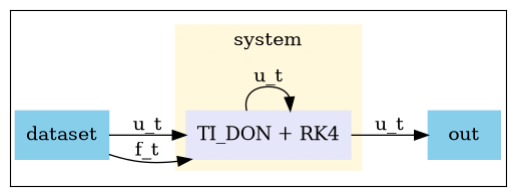

In [20]:
dynamics_model.show()

## Objective and Constraints in NeuroMANCER

**Loss Function.** We utilize a fully data-driven approach using Mean Squared Error (MSE). The loss is calculated by comparing the ground truth data $u_{t+1}$ against the predicted state $\hat{u}_{t+1}$, which is obtained by integrating the DeepONet output through an RK4 step:

$$
\mathcal{L} = \frac{1}{N} \sum_{i=1}^{N} \left( \hat{u}_{t+1}^{(i)} - u_{t+1}^{(i)} \right)^2
$$

In [21]:
from neuromancer.problem import Problem
from neuromancer.constraint import variable
from neuromancer.loss import PenaltyLoss
from neuromancer.constraint import Objective

var_y_est = variable("u_t")
var_y_true = variable("outputs")

# MSE over rollout
mse_var = (var_y_est - var_y_true) ** 2
mse_obj = Objective(mse_var, metric=torch.mean, name="mse_loss")

loss = PenaltyLoss(objectives=[mse_obj], constraints=[])


## Problem Solution in NeuroMANCER

In [30]:
# Use System for rollout training
problem = Problem(
    nodes=[dynamics_model],
    loss=loss,
    #   grad_inference=True
)


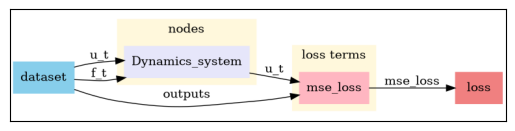

In [31]:
problem.show()  # graphviz library needed for graph visualization

## Training the TI-DON

In [32]:
# result_dir = './'
epochs = int(1)  # 10 passes of 1000 steps each
log_every = 100
lr = 1e-3
transition_steps = 2000
decay_rate = 0.9

The learning rate is updated at each optimizer step using an exponential decay schedule,
$$
\eta_k = \eta_0 \, \gamma^{\,k / T},
$$
where $\eta_0$ is the base learning rate (`lr`), $ \gamma \in (0,1) $ is the decay rate (`decay_rate`), $ k $ denotes the optimizer step index, and $ T $ is the transition scale (`transition_steps`) controlling the decay speed.


In [33]:
from torch.optim.lr_scheduler import LambdaLR
from neuromancer.callbacks import Callback

optimizer = torch.optim.Adam(problem.parameters(), lr=lr)


def exponential_decay(step: int) -> float:
    """Exponential learning-rate decay applied per optimizer step."""
    return decay_rate ** (step / transition_steps)


scheduler = LambdaLR(optimizer, lr_lambda=exponential_decay)

The custom callback `StepLRSchedulerCallback` updates the learning rate at every training step (batch) and optionally logs the training loss at a fixed step interval.

It gives the printed format:
`epoch: <epoch> step: <step_in_epoch> <loss_name>: <loss_value>`

In [34]:
class StepLRSchedulerCallback(Callback):
    """
    Scheduler that steps every batch end, and logs loss every `log_every`.

    Args:
        scheduler: Learning rate scheduler to step.
        log_every: Frequency of logging loss (in number of steps). If 0, no logging.
        global_step: Internal counter for total steps taken.
        epoch_step: Counter for steps within the current epoch.
        step_indices: List of global step indices where loss was logged.
        step_losses: List of losses corresponding to the logged step indices.
    """

    def __init__(self, scheduler, log_every=1):
        super().__init__()
        self.scheduler = scheduler
        self.log_every = log_every
        self.global_step = 0
        self._last_epoch = None
        self.epoch_step = 0
        self.step_indices = []
        self.step_losses = []

    def end_batch(self, trainer, output):
        if self._last_epoch != trainer.current_epoch:
            self._last_epoch = trainer.current_epoch
            self.epoch_step = 0

        self.scheduler.step()

        if self.log_every and self.epoch_step % self.log_every == 0:
            loss = output.get(trainer.train_metric)
            if loss is not None:
                loss_val = loss.detach().cpu().item()
                print(
                    f"epoch: {trainer.current_epoch} step: {self.epoch_step} "
                    f"{trainer.train_metric}: {loss_val:.6g}"
                )
                self.step_indices.append(self.global_step)
                self.step_losses.append(loss_val)

        self.epoch_step += 1
        self.global_step += 1


lr_callback = StepLRSchedulerCallback(scheduler, log_every=100)  # set as needed

### Construct Trainer and solve the problem

In [35]:
from neuromancer.trainer import Trainer

trainer = Trainer(
    problem.to(device),
    train_data=train_loader,
    # dev_data=dev_loader,        # optional
    test_data=test_loader,
    optimizer=optimizer,
    callback=lr_callback,
    epochs=epochs,
    epoch_verbose=1,
    train_metric="train_loss",
    dev_metric="train_loss",  # or "dev_loss" if you use dev_data
    eval_metric="train_loss",
    test_metric="test_loss",
    warmup=epochs,
    device=device,
)

In [37]:
%%time
best_model = trainer.train()

CPU times: user 5.54 s, sys: 91.8 ms, total: 5.63 s
Wall time: 271 ms


RuntimeError: The size of tensor a (2) must match the size of tensor b (401) at non-singleton dimension 1

In [29]:
# load best trained model
trainer.dev_data = trainer.train_data  # workaround for replacing dev set to match keys
best_outputs = trainer.test(best_model)
problem.load_state_dict(best_model)

<All keys matched successfully>

In [30]:
train_loss_history = [l.detach().cpu().numpy() for l in trainer.loss_history["train"]]
mean_test_loss = best_outputs["mean_test_loss"].detach().cpu().numpy()
print(f"mean_test_loss: {mean_test_loss}")
print(f"len(train_loss_history): {len(train_loss_history)}")


mean_test_loss: 0.00011354911111993715
len(train_loss_history): 1


## Plot loss history w/ mean test loss

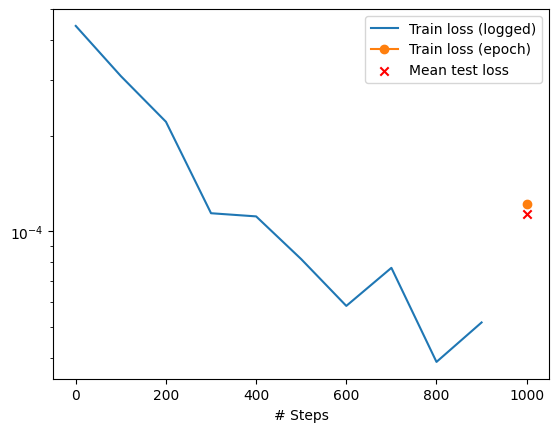

In [31]:
epoch_steps = (np.arange(len(train_loss_history)) + 1) * steps_per_epoch

plt.semilogy(
    lr_callback.step_indices, lr_callback.step_losses, label="Train loss (logged)"
)
plt.semilogy(epoch_steps, train_loss_history, "o-", label="Train loss (epoch)")

plt.scatter(
    epoch_steps[-1],
    mean_test_loss,
    label="Mean test loss",
    c="red",
    marker="x",
)

plt.xlabel("# Steps")
plt.legend()
plt.show()


## Test time predictions

In [32]:
def autoregressive_rollout(sample_id_value, rollout_steps=None):
    system = dynamics_model.to(device)
    system.eval()

    with torch.no_grad():
        u0 = solutions[sample_id_value, 0, :].float().to(device)
        true_states = solutions[sample_id_value, :, :].float().to(device)
        control_seq = controls[sample_id_value, :, :].float().to(device)

        if rollout_steps is None:
            rollout_steps = control_seq.shape[0]
        system.nsteps = rollout_steps

        batch = {
            "u_t": u0.unsqueeze(0).unsqueeze(1),  # (B, 1, N)
            "f_t": control_seq[:rollout_steps].unsqueeze(0),  # (B, T, 4)
        }
        out = system(batch)
        rollout_pred = out["u_t"].squeeze(0)  # (T+1, N)

        true_traj = true_states[: rollout_steps + 1]
        mse_loss = torch.mean((true_traj - rollout_pred) ** 2)
        rel_l2_error = torch.linalg.norm(true_traj - rollout_pred) / torch.linalg.norm(
            true_traj
        )

    return mse_loss, rel_l2_error, rollout_pred, true_traj


In [33]:
sample_id = 12  # change this to test other samples
mse_loss, rel_l2_error, rollout_pred, true_states = autoregressive_rollout(sample_id)
print(mse_loss.item(), rel_l2_error.item())

0.45731842517852783 0.7068629860877991


In [34]:
import matplotlib.gridspec as gridspec


def plot_rollout_results(
    true_states,
    rollout_pred,
    x_cord,
    dt_value,
    sample_id_value,
):
    x_axis = x_cord.squeeze()
    T_plus_1 = true_states.shape[0]
    time_axis = np.linspace(0, dt_value * (T_plus_1 - 1), T_plus_1)
    error = np.abs(true_states - rollout_pred)

    vmin = float(min(true_states.min(), rollout_pred.min()))
    vmax = float(max(true_states.max(), rollout_pred.max()))

    fig = plt.figure(figsize=(20, 10))
    gs = gridspec.GridSpec(
        3,
        3,
        height_ratios=[20, 0.3, 1.0],
        width_ratios=[1, 1, 1],
        hspace=0.15,
        wspace=0.2,
        bottom=0.15,
        top=0.88,
        left=0.08,
        right=0.95,
    )

    ax0 = fig.add_subplot(gs[0, 0])
    ax1 = fig.add_subplot(gs[0, 1], sharey=ax0)
    ax2 = fig.add_subplot(gs[0, 2], sharey=ax0)

    im0 = ax0.contourf(
        x_axis, time_axis, true_states, levels=120, cmap="inferno", vmin=vmin, vmax=vmax
    )
    ax0.set_title("FDM Prediction", fontsize=22)
    ax0.set_xlabel("x", fontsize=20)
    ax0.set_ylabel("t", fontsize=20)
    ax0.tick_params(labelsize=18)

    im1 = ax1.contourf(
        x_axis,
        time_axis,
        rollout_pred,
        levels=120,
        cmap="inferno",
        vmin=vmin,
        vmax=vmax,
    )
    ax1.set_title("TI DON Prediction", fontsize=22)
    ax1.set_xlabel("x", fontsize=20)
    ax1.tick_params(labelsize=18, labelleft=False)

    im2 = ax2.contourf(x_axis, time_axis, error, levels=120, cmap="magma")
    ax2.set_title("Absolute Error", fontsize=22)
    ax2.set_xlabel("x", fontsize=20)
    ax2.tick_params(labelsize=18, labelleft=False)

    cbar_ax1 = fig.add_subplot(gs[2, 0:2])
    cbar1 = fig.colorbar(im1, cax=cbar_ax1, orientation="horizontal")
    cbar1.set_label("u", fontsize=20)
    cbar1.ax.tick_params(labelsize=18)

    cbar_ax2 = fig.add_subplot(gs[2, 2])
    cbar2 = fig.colorbar(im2, cax=cbar_ax2, orientation="horizontal")
    cbar2.set_label("Abs. Error", fontsize=20)
    cbar2.ax.tick_params(labelsize=18)

    plt.show()


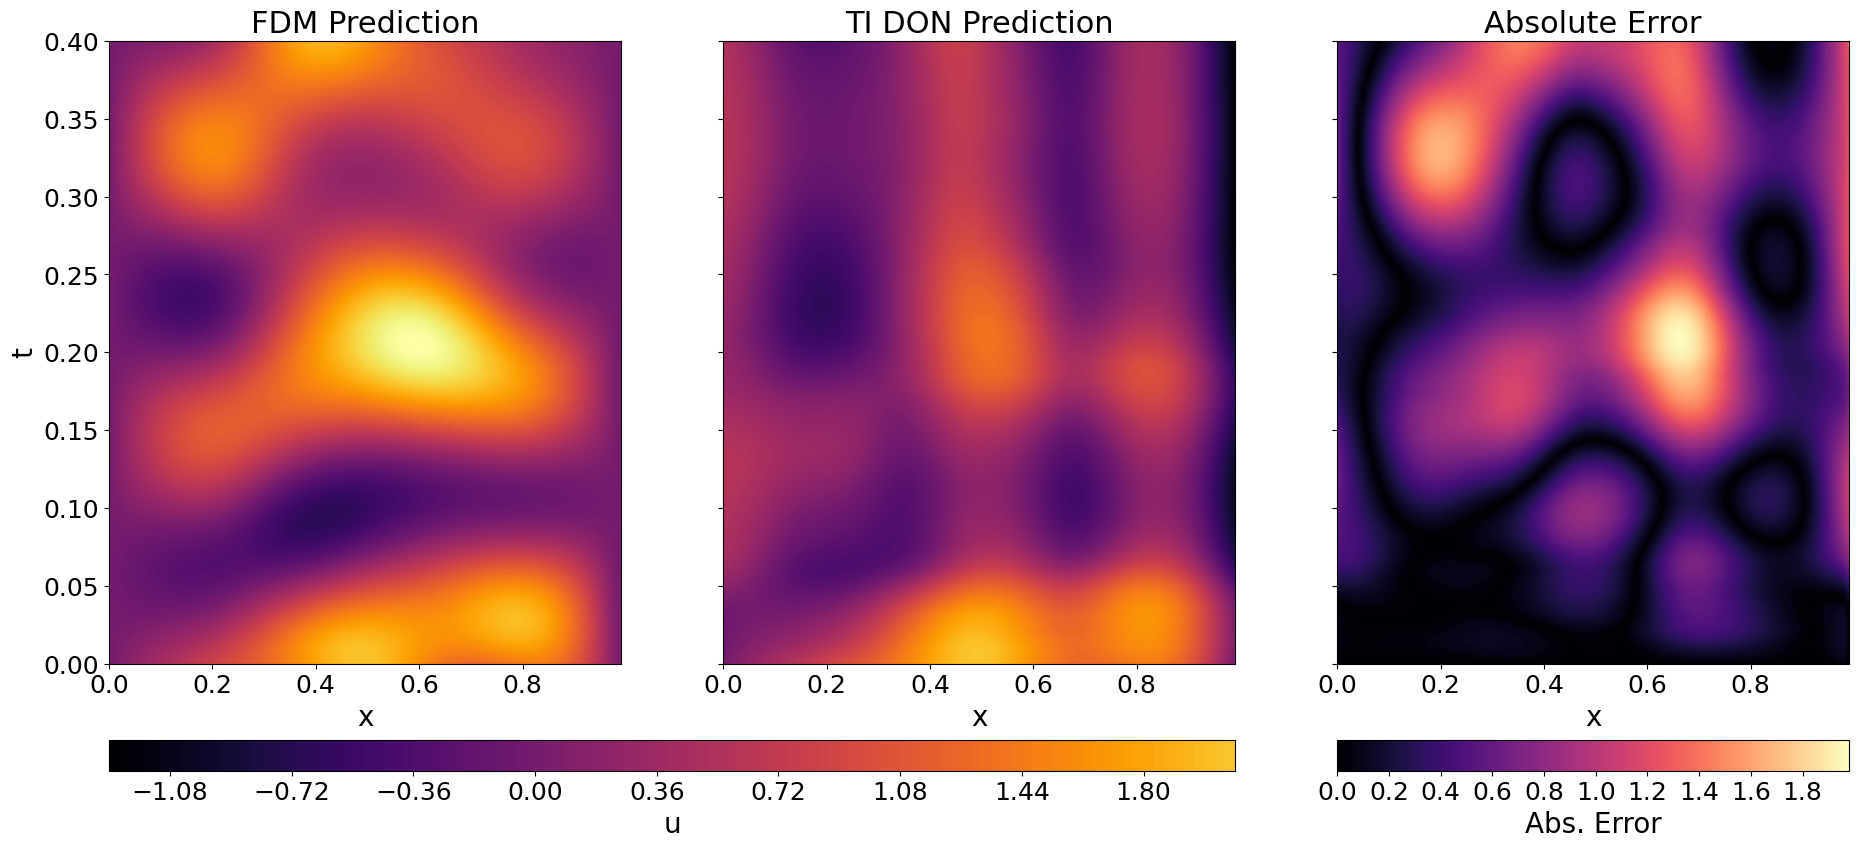

In [35]:
# assumes plot_rollout_results is already defined


def rollout_and_plot(sample_id_value, rollout_steps=None):
    mse_loss, rel_l2_error, rollout_pred, true_states = autoregressive_rollout(
        sample_id_value, rollout_steps=rollout_steps
    )

    plot_rollout_results(
        true_states.detach().cpu().numpy(),
        rollout_pred.detach().cpu().numpy(),
        x_cord.detach().cpu().numpy(),
        dt,
        sample_id_value,
    )


# run it
rollout_and_plot(sample_id)
